# I will now be building the basic arithmetic operations from the Clifford + T gate set

Allowed gates are Clifford gates: H, S, X, Y, Z, I, CNOT and all of their inverses  (add to this list any other Clifford gate I need, this isn't meant to be exhaustive)

and the only non-Clifford gate allowed is T

In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator, Statevector
import numpy as np
from matplotlib import pyplot as plt

from Elementary_circuits import subarithmetic_circuits
from Elementary_circuits import basic_arithmetic_circuits

# In-place 1s Complement
Taking some binary representation of an integer, apply the X gate to every qubit:

$\ket{a}^n \rightarrow \ket{2^n - a - 1}^n$

$\ket{a}^n = \ket{a_{n}} \ket{a_{n-1}} \ldots \ket{a_0} \rightarrow \ket{a_{n} \oplus 1} \ket{a_{n-1} \oplus 1} \ldots \ket{a_0 \oplus 1}$

All tests passed.
{'x': 3}


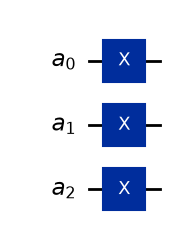

In [2]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register

qc = QuantumCircuit(a)

basic_arithmetic_circuits.Ones_complement_inplace(qc, a)

# get the unitary of the circuit
#U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
allTestsPassed = True
for a_val in range(int(2**n)):
    # Create the input state for a given integer a_val
    integer_input = a_val
    bit_string_input = format(integer_input, '0' + str(n) + 'b')
    input_state = Statevector.from_int(integer_input, dims=2**(n))

    # Apply the circuit to the state and get the output state
    output_state = input_state.evolve(qc)
    output_a = np.argmax(output_state.data)
    bit_string_output = format(output_a, '0' + str(n) + 'b')

    # print the input and output bit string for each test case
    #print("input: ", bit_string_input, "   a = ", a_val)
    #print("output: ", bit_string_output, "   a = ", output_a)

    # test that output is correct
    if output_a != int(2**n) - a_val - 1:
        allTestsPassed = False
        print("output a is not correct")
        print("input: ", bit_string_input, "   a = ", a_val)
        print("output: ", bit_string_output, "   a = ", output_a)
        #raise Exception("output a is not correct")


if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')

# Out-of-place 1s Complement
Preserve the input register and store its one's complement in a separate zeroed result register:

$\ket{a}^n \ket{0}^n \rightarrow \ket{a}^n \ket{2^n - a - 1}^n$

All tests passed.
{'cx': 3, 'x': 3}


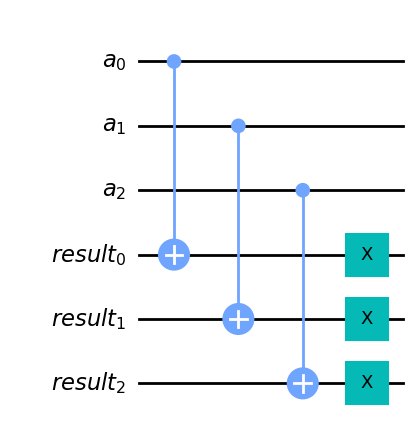

In [3]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # input register
result = QuantumRegister(n, 'result') # zeroed output register

qc = QuantumCircuit(a, result)
basic_arithmetic_circuits.Ones_complement_outofplace(qc, a, result)

# get the unitary of the circuit
#U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# Test every computational-basis input.
allTestsPassed = True
for a_val in range(2**n):
    # Create the input state for a given integer a_val
    integer_input = a_val
    bit_string_input = format(integer_input, '0' + str(2*n) + 'b')
    input_state = Statevector.from_int(integer_input, dims=2**(2*n))

    # Apply the circuit to the state and get the output state
    output_state = input_state.evolve(qc)
    output_value = int(np.argmax(np.abs(output_state.data)))
    bit_string_output = format(output_value, '0' + str(2*n) + 'b')
    output_a = output_value % (2**n)
    output_result = output_value // (2**n)

    # print the input and output bit string for each test case
    #print("input: ", bit_string_input, "   a = ", a_val)
    #print("output: ", bit_string_output, "   a = ", output_a, "  result = ", output_result)

    # test that output is correct
    if output_result != int(2**n) - a_val - 1 or output_a != a_val:
        allTestsPassed = False
        print("output is not correct")
        print("input: ", bit_string_input, "   a = ", a_val)
        print("output: ", bit_string_output, "   a = ", output_a)
        #raise Exception("output a is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')

# In-place Modular Addition
$\ket{a}^n \ket{b}^{n} \rightarrow \ket{a}^n \ket{(a+b) \% 2^{n}}^{n}$

All tests passed.
{'barrier': 9, 'cx': 7, 'ccx': 2, 'unitary': 2}


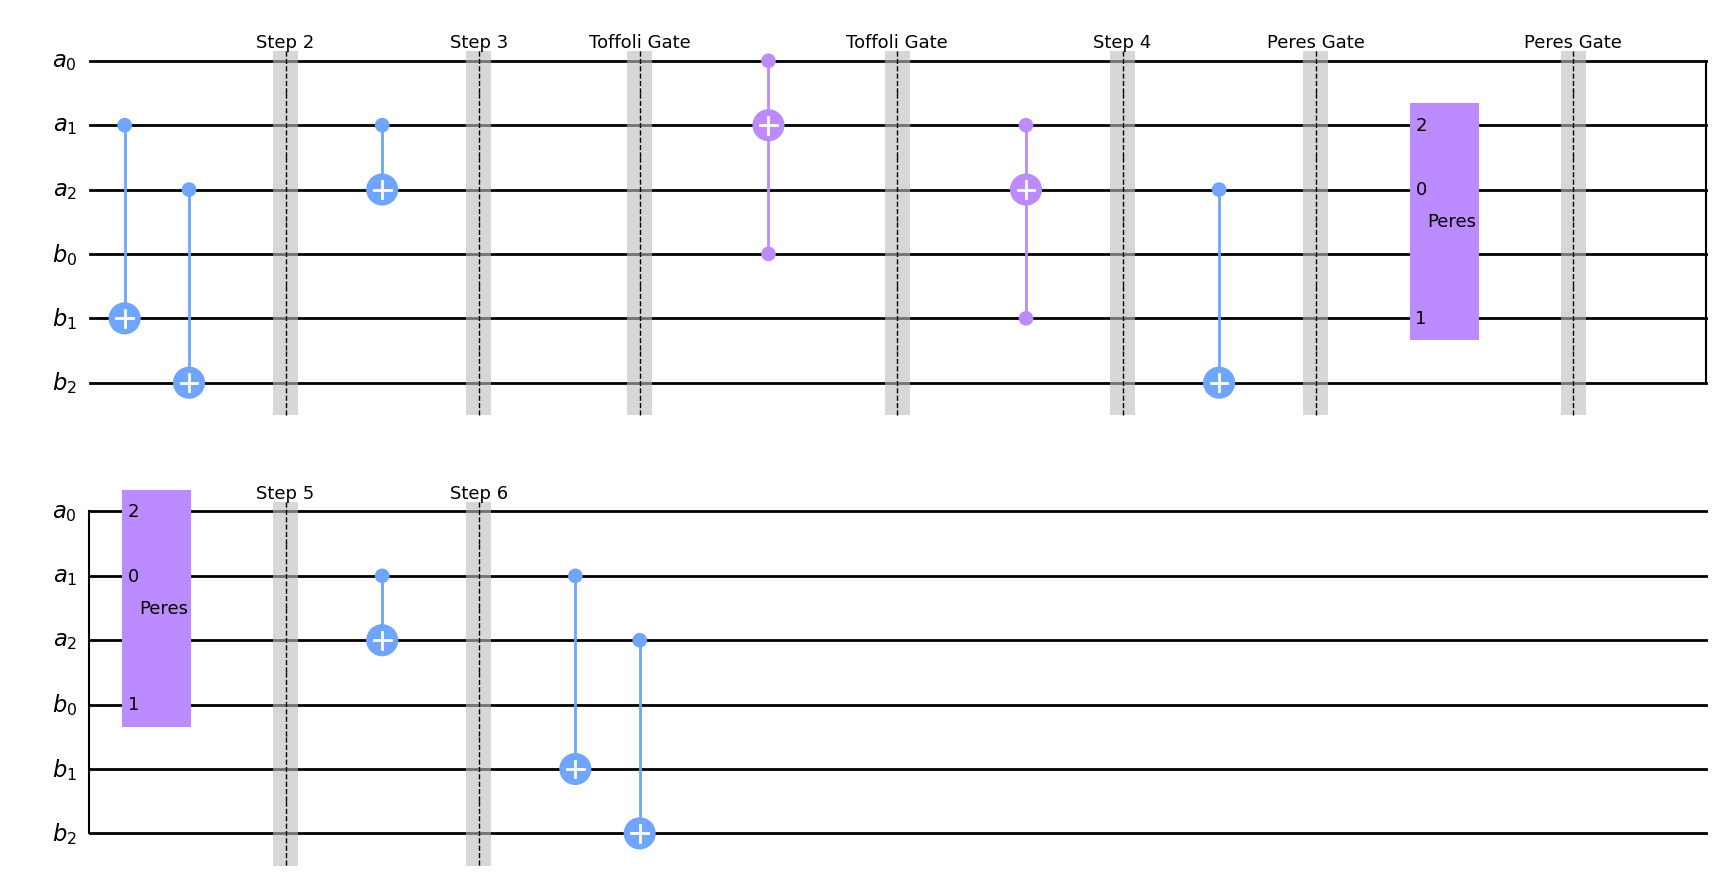

In [4]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register
b = QuantumRegister(n, 'b') # "B" register

qc = QuantumCircuit(a, b)

basic_arithmetic_circuits.Addition_gate_inplace(qc, a, b, modular=True, useElementaryGates=False)

# get the unitary of the circuit
#U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
allTestsPassed = True
for b_val in range(int(2**n)):
    for a_val in range(int(2**n)):
        # Create the input state for a given integer a_val and b_val
        integer_input = b_val * int(2**n) + a_val
        bit_string_input = format(integer_input, '0' + str(2*n) + 'b')
        input_state = Statevector.from_int(integer_input, dims=2**(2*n))

        # Apply the circuit to the state and get the output state
        output_state = input_state.evolve(qc)
        integer_output = np.argmax(output_state.data)
        bit_string_output = format(integer_output, '0' + str(2*n) + 'b')
        output_a = integer_output % int(2**n)
        output_b = integer_output // int(2**n)

        # print the input and output bit string for each test case
        #print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
        #print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b)

        # test that output is correct
        if output_a != a_val or output_b != (a_val + b_val) % int(2**n):
            allTestsPassed = False
            print("output is not correct")
            print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
            print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b)
            #raise Exception("output is not correct")


if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')

# In-place Full Addition
$\ket{a}^n \ket{b}^{n} \ket{0} \rightarrow \ket{a}^n \ket{a+b}^{n+1} $

All tests passed.
{'barrier': 9, 'cx': 7, 'unitary': 3, 'ccx': 2}


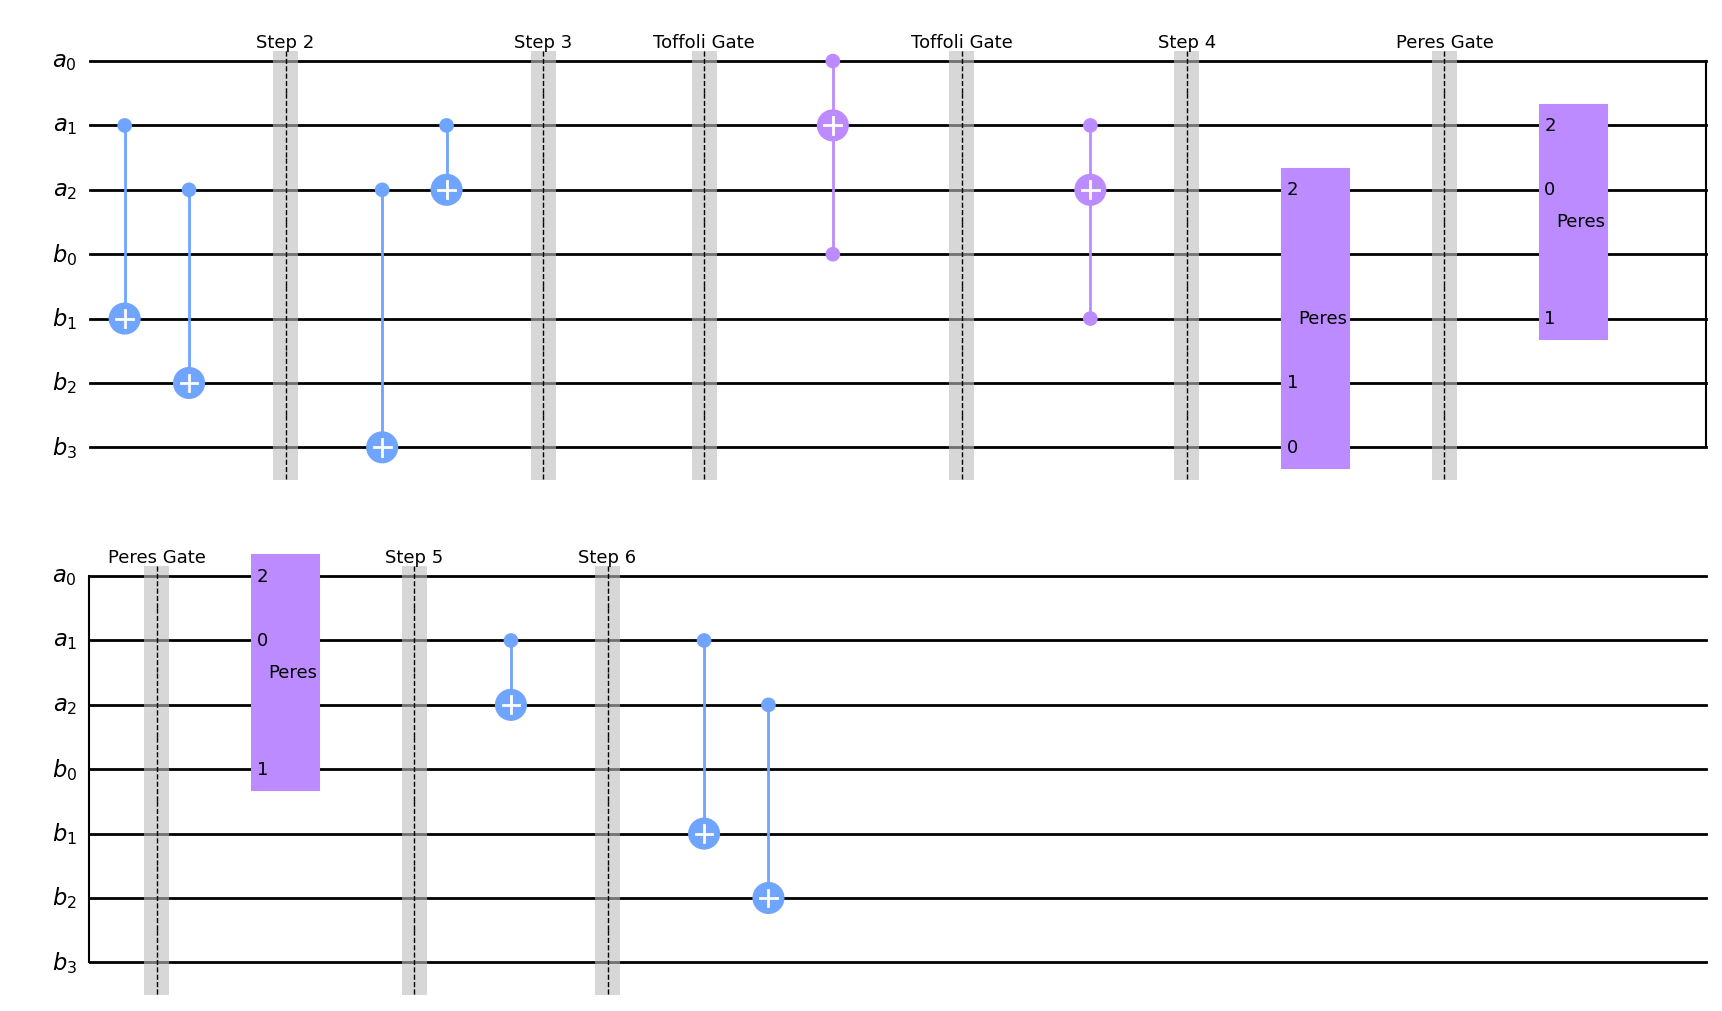

In [5]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register
b = QuantumRegister(n+1, 'b') # "B" register

qc = QuantumCircuit(a, b)

basic_arithmetic_circuits.Addition_gate_inplace(qc, a, b, modular=False, useElementaryGates=False)

# get the unitary of the circuit
#U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
allTestsPassed = True
for b_val in range(int(2**n)):
    for a_val in range(int(2**n)):
        # Create the input state for a given integer a_val and b_val
        integer_input = b_val * int(2**n) + a_val
        bit_string_input = format(integer_input, '0' + str(2*n+1) + 'b')
        input_state = Statevector.from_int(integer_input, dims=2**(2*n+1))

        # Apply the circuit to the state and get the output state
        output_state = input_state.evolve(qc)
        integer_output = np.argmax(output_state.data)
        bit_string_output = format(integer_output, '0' + str(2*n+1) + 'b')
        output_a = integer_output % int(2**n)
        output_b = integer_output // int(2**n)

        # print the input and output bit string for each test case
        #print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
        #print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b)

        # test that output is correct
        if output_a != a_val or output_b != (a_val + b_val):
            allTestsPassed = False
            print("output is not correct")
            print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
            print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b)
            #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')

# Out-of-place Modular Addition
$\ket{a}^n \ket{b}^{n} \ket{0}^{n} \rightarrow \ket{a}^n \ket{b}^{n} \ket{(a+b) \% 2^{n}}^{n}$

All tests passed.
{'cx': 10, 'barrier': 9, 'ccx': 2, 'unitary': 2}


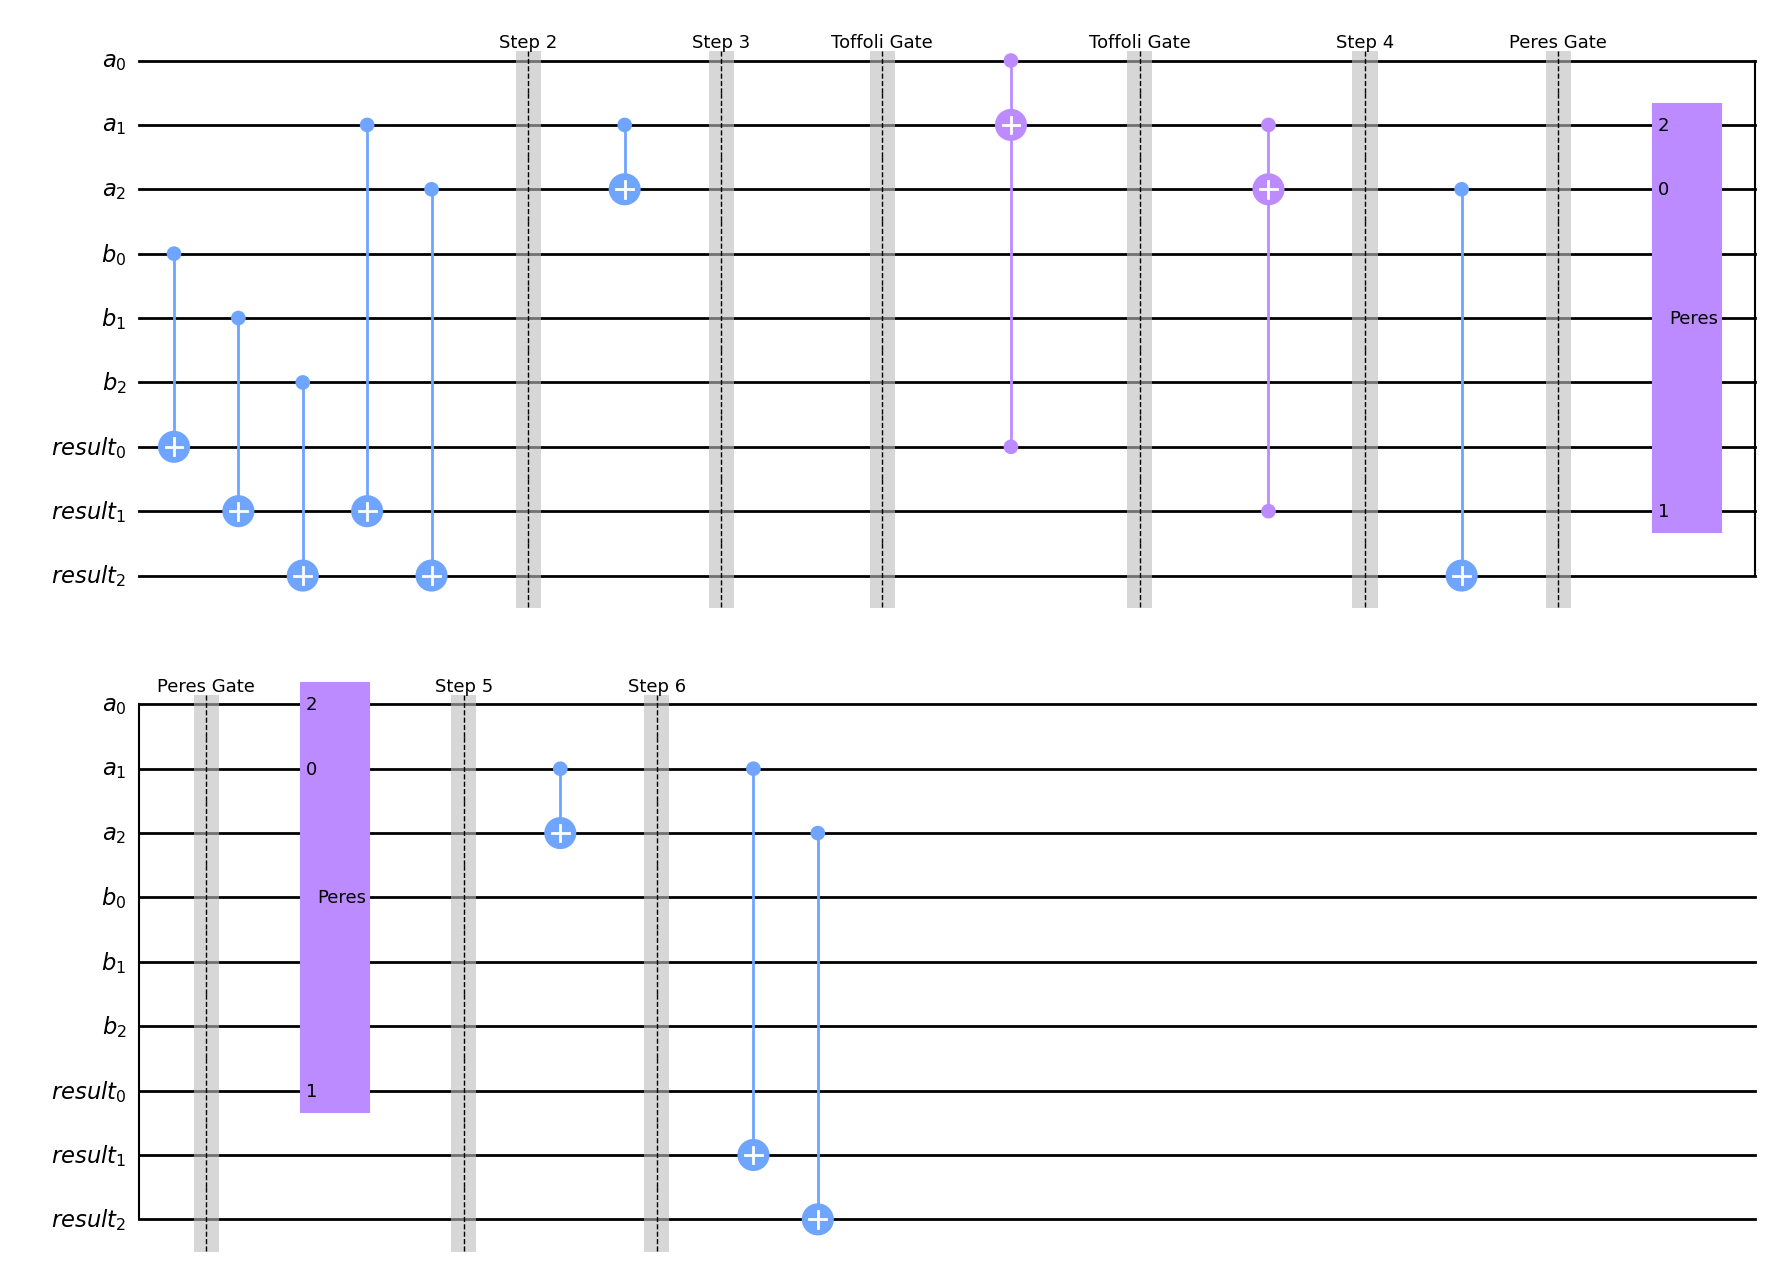

In [6]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" input register
b = QuantumRegister(n, 'b') # "B" input register
result = QuantumRegister(n, 'result') # zeroed output register

qc = QuantumCircuit(a, b, result)

basic_arithmetic_circuits.Addition_gate_outofplace(qc, a, b, result, modular=True, useElementaryGates=False)

# get the unitary of the circuit
#U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
register_size = int(2**n)
allTestsPassed = True
for b_val in range(register_size):
    for a_val in range(register_size):
        # Create the input state for given integers a_val and b_val
        integer_input = b_val * register_size + a_val
        bit_string_input = format(integer_input, '0' + str(3*n) + 'b')
        input_state = Statevector.from_int(integer_input, dims=2**(3*n))

        # Apply the circuit to the state and get the output state
        output_state = input_state.evolve(qc)
        integer_output = int(np.argmax(np.abs(output_state.data)))
        bit_string_output = format(integer_output, '0' + str(3*n) + 'b')
        output_a = integer_output % register_size
        output_b = (integer_output // register_size) % register_size
        output_result = (integer_output // register_size**2) % register_size

        # print the input and output bit string for each test case
        #print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
        #print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b, "  result = ", output_result)

        # test that output is correct
        if output_a != a_val or output_b != b_val or output_result != (a_val + b_val) % register_size:
            allTestsPassed = False
            print("output is not correct")
            print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
            print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b, "  result = ", output_result)
            #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')

# Out-of-place Full Addition
$\ket{a}^n \ket{b}^{n} \ket{0} \ket{0}^{n+1} \rightarrow \ket{a}^n \ket{b}^{n} \ket{0}  \ket{a+b}^{n+1}$

The most-significant input qubit of $b$ starts in $\ket{0}$ and is preserved.

All tests passed.
{'cx': 11, 'barrier': 9, 'unitary': 3, 'ccx': 2}


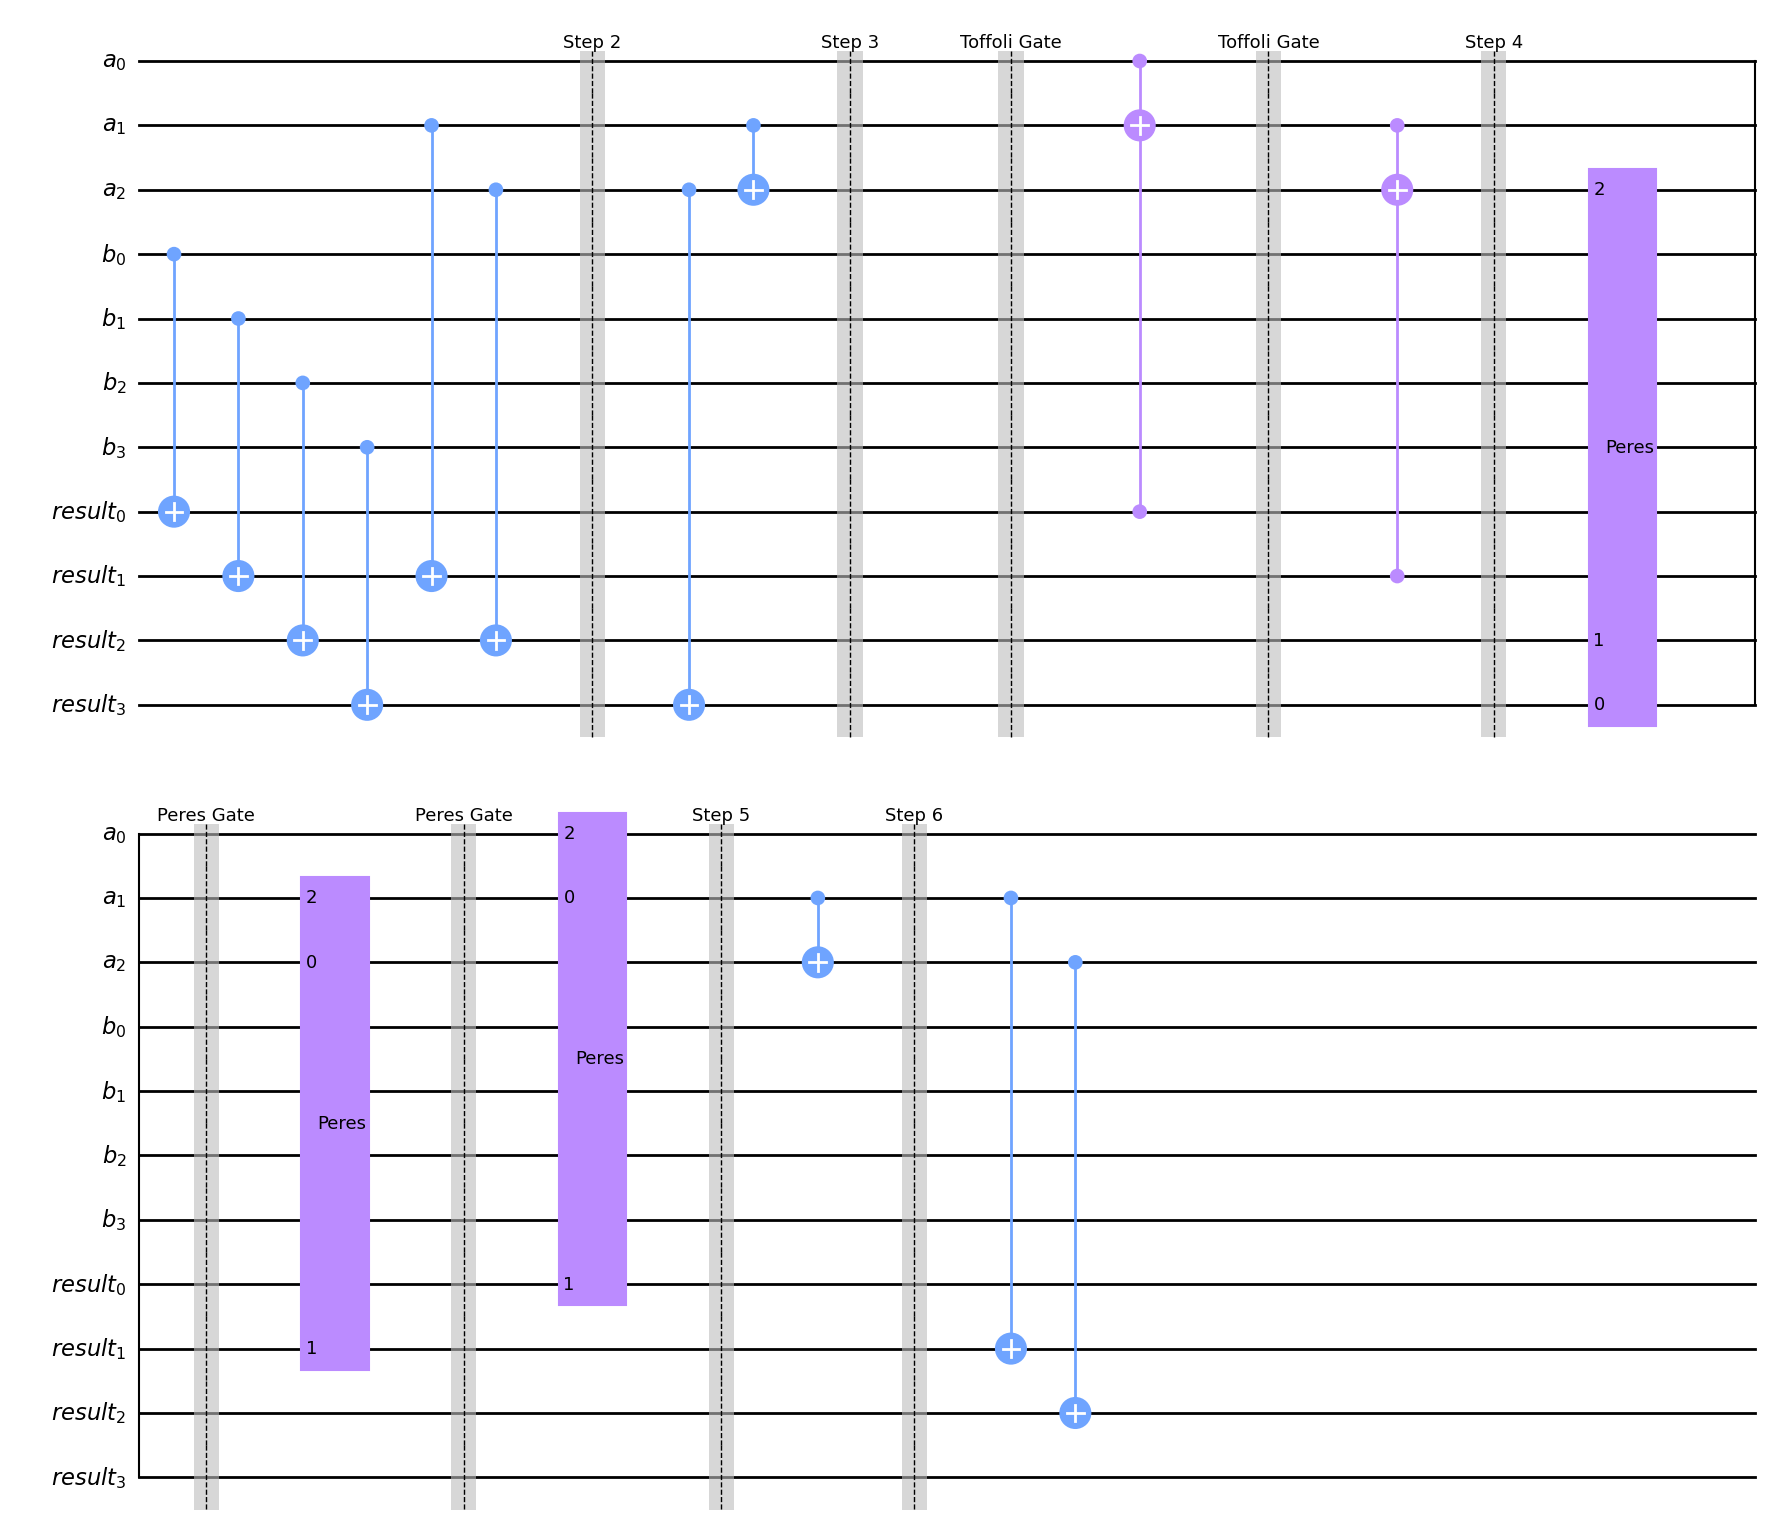

In [7]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" input register
b = QuantumRegister(n+1, 'b') # "B" input register with a zeroed high bit
result = QuantumRegister(n+1, 'result') # zeroed full-sum register

qc = QuantumCircuit(a, b, result)

basic_arithmetic_circuits.Addition_gate_outofplace(qc, a, b, result, modular=False, useElementaryGates=False)

# get the unitary of the circuit
#U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
input_size = int(2**n)
full_size = int(2**(n+1))
allTestsPassed = True
for b_val in range(input_size):
    for a_val in range(input_size):
        # Create the input state for given integers a_val and b_val
        integer_input = b_val * input_size + a_val
        bit_string_input = format(integer_input, '0' + str(3*n+2) + 'b')
        input_state = Statevector.from_int(integer_input, dims=2**(3*n+2))

        # Apply the circuit to the state and get the output state
        output_state = input_state.evolve(qc)
        integer_output = int(np.argmax(np.abs(output_state.data)))
        bit_string_output = format(integer_output, '0' + str(3*n+2) + 'b')
        output_a = integer_output % input_size
        output_b = (integer_output // input_size) % full_size
        output_result = (integer_output // int(2**(2*n+1))) % full_size

        # print the input and output bit string for each test case
        #print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
        #print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b, "  result = ", output_result)

        # test that output is correct
        if output_a != a_val or output_b != b_val or output_result != (a_val + b_val):
            allTestsPassed = False
            print("output is not correct")
            print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
            print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b, "  result = ", output_result)
            #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')

# In-place Modular Integer Subtraction

$\ket{a}^n \ket{b}^n \rightarrow \ket{a}^n \ket{(b-a) \% 2^n}^n$

All tests passed.
{'barrier': 9, 'cx': 7, 'unitary': 2, 'ccx': 2}


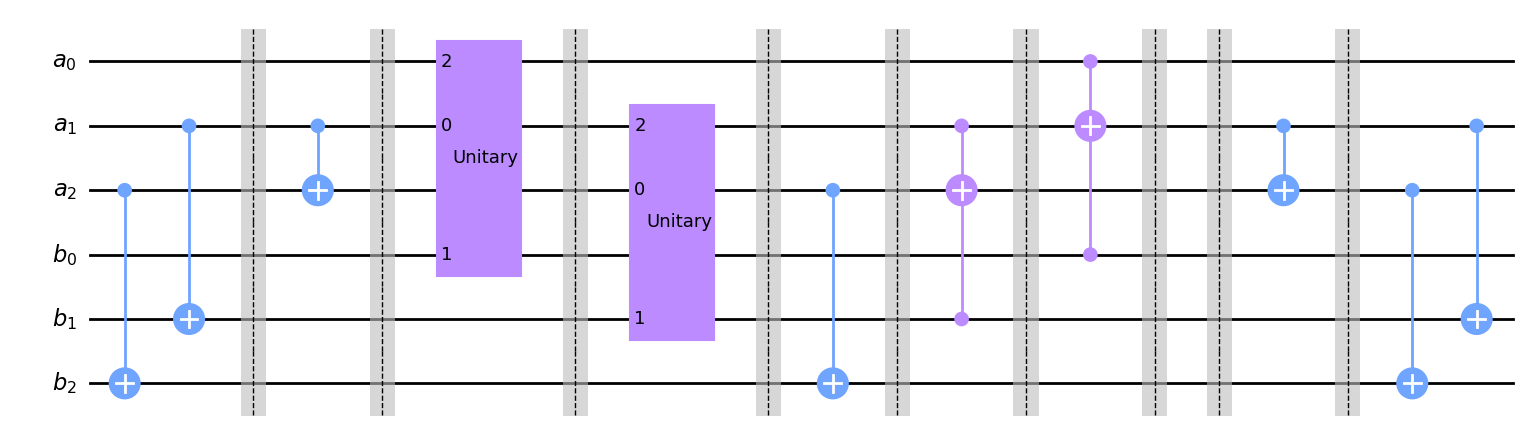

In [8]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # subtrahend register
b = QuantumRegister(n, 'b') # minuend and result register

qc = QuantumCircuit(a, b)
basic_arithmetic_circuits.Integer_subtraction_gate_inplace(
    qc, a, b, useElementaryGates=False
)

# Test every computational-basis input pair.
allTestsPassed = True
for a_val in range(2**n):
    for b_val in range(2**n):
        # Create the input state for given integers a_val and b_val
        integer_input = b_val * input_size + a_val
        bit_string_input = format(integer_input, '0' + str(2*n) + 'b')
        input_state = Statevector.from_int(integer_input, dims=2**(2*n))

        # Apply the circuit to the state and get the output state
        output_state = input_state.evolve(qc)
        integer_output = int(np.argmax(np.abs(output_state.data)))
        bit_string_output = format(integer_output, '0' + str(2*n) + 'b')
        output_a = integer_output % (2**n)
        output_b = integer_output // (2**n)

        # print the input and output bit string for each test case
        #print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
        #print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b)

        # test that output is correct
        if output_a != a_val or output_b != (b_val - a_val) % (2**n):
            allTestsPassed = False
            print("output is not correct")
            print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
            print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b)
            #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')

# Out-of-place Modular Integer Subtraction

$\ket{a}^n \ket{b}^{n} \rightarrow \ket{a}^n \ket{b}^{n} \ket{(b-a) \% 2^n}^n$

All tests passed.
{'cx': 10, 'barrier': 9, 'unitary': 2, 'ccx': 2}


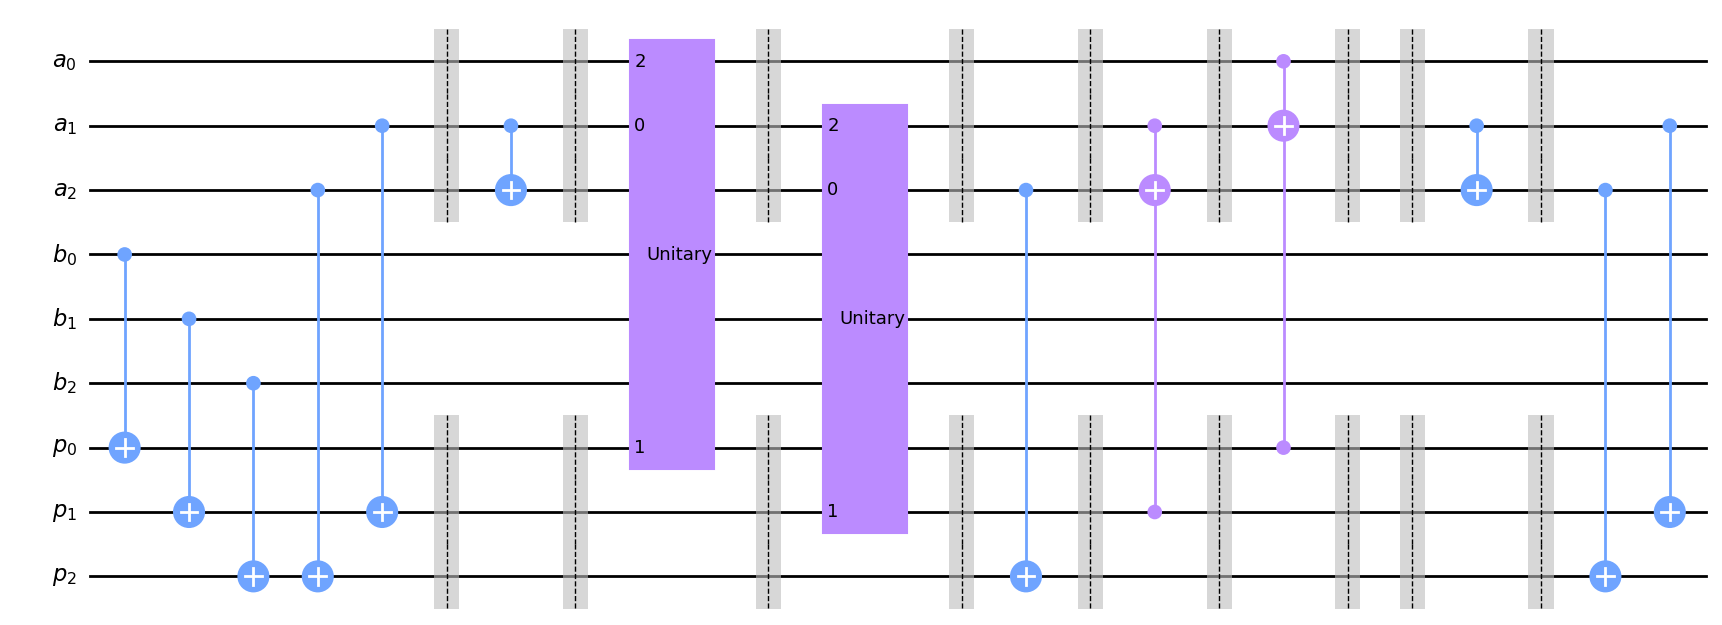

In [9]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # subtrahend register
b = QuantumRegister(n, 'b') # minuend register
p = QuantumRegister(n, 'p') # difference register, initialized to zero

qc = QuantumCircuit(a, b, p)

basic_arithmetic_circuits.Integer_subtraction_gate_outofplace(qc, a, b, p, useElementaryGates=False)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# Exhaustively test all n-bit unsigned inputs.
register_size = int(2**n)
allTestsPassed = True
for b_val in range(register_size):
    for a_val in range(register_size):
        # Create the input state for given integers a_val and b_val
        integer_input = b_val * register_size + a_val
        bit_string_input = format(integer_input, '0' + str(3*n) + 'b')
        input_state = Statevector.from_int(integer_input, dims=2**(3*n))

        # Apply the circuit to the state and get the output state
        output_state = input_state.evolve(qc)
        integer_output = int(np.argmax(np.abs(output_state.data)))
        bit_string_output = format(integer_output, '0' + str(3*n) + 'b')
        output_a = integer_output % register_size
        output_b = (integer_output // register_size) % register_size
        output_p = (integer_output // (register_size**2)) % register_size

        # print the input and output bit string for each test case
        #print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
        #print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b, "  p = ", output_p)

        # test that output is correct
        if output_a != a_val or output_b != b_val or output_p != (b_val - a_val) % register_size:
            allTestsPassed = False
            print("output is not correct")
            print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
            print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b, "  p = ", output_p)
            #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')

# In-place Modular Conditional Addition

$\ket{c}\ket{a}^n\ket{b}^n\ket{0}\ket{0} \rightarrow \ket{c}\ket{a}^n\ket{(b+ca) \% 2^n}^n\ket{0}\ket{0}$

All tests passed.


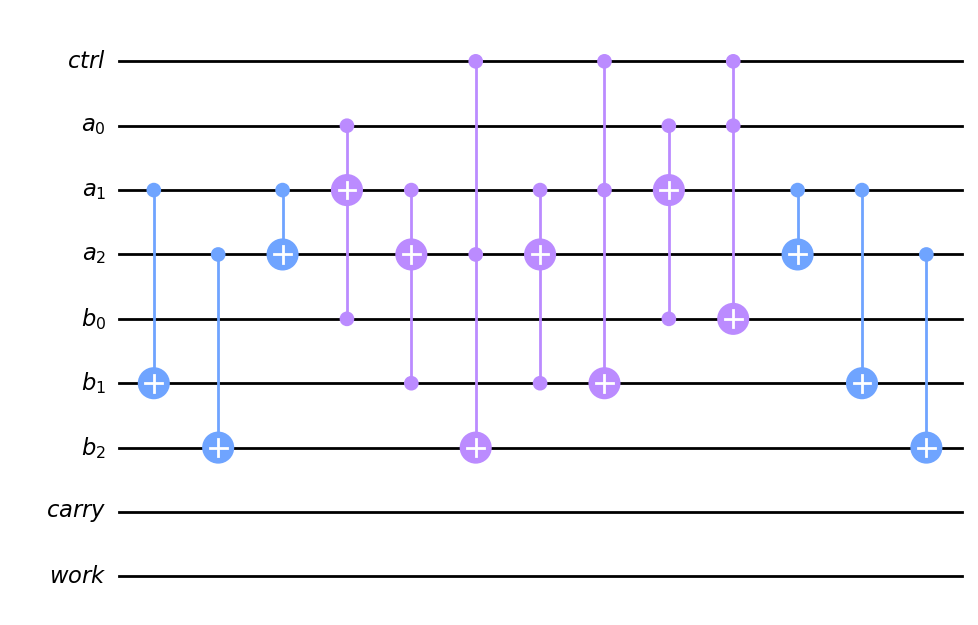

In [10]:
n = 3
ctrl = QuantumRegister(1, 'ctrl')
a = QuantumRegister(n, 'a')
b = QuantumRegister(n, 'b')
carry = QuantumRegister(1, 'carry')
work = QuantumRegister(1, 'work')
qc = QuantumCircuit(ctrl, a, b, carry, work)

basic_arithmetic_circuits.Conditional_addition_gate_inplace(
    qc, ctrl[0], a, b, carry[0], work[0],
    modular=True, useElementaryGates=False
)

mask = 2**n - 1
allTestsPassed = True
for ctrl_val in range(2):
    for a_val in range(2**n):
        for b_val in range(2**n):
            # Create the input state for given integers ctrl_val, a_val, and b_val
            integer_input = ctrl_val + (a_val << 1) + (b_val << (n + 1))
            bit_string_input = format(integer_input, '0' + str(qc.num_qubits) + 'b')
            input_state = Statevector.from_int(integer_input, dims=2**qc.num_qubits)

            # Apply the circuit to the state and get the output state
            output_state = input_state.evolve(qc)
            integer_output = int(np.argmax(np.abs(output_state.data)))
            bit_string_output = format(integer_output, '0' + str(qc.num_qubits) + 'b')
            output_ctrl = integer_output & 1
            output_a = (integer_output >> 1) & mask
            output_b = (integer_output >> (n + 1)) & mask
            output_carry = (integer_output >> (2*n + 1)) & 1
            output_work = (integer_output >> (2*n + 2)) & 1
            expected_sum = (b_val + ctrl_val*a_val) % 2**n

            # print the input and output bit string for each test case
            #print("input: ", bit_string_input, "   ctrl = ", ctrl_val, "  a = ", a_val, "  b = ", b_val)
            #print("output: ", bit_string_output, "   ctrl = ", output_ctrl, "  a = ", output_a, "  b = ", output_b, "  carry = ", output_carry, "  work = ", output_work)

            # test that output is correct
            if output_ctrl != ctrl_val or output_a != a_val or output_b != expected_sum or output_carry != 0 or output_work != 0:
                allTestsPassed = False
                print("output is not correct")
                print("input: ", bit_string_input, "   ctrl = ", ctrl_val, "  a = ", a_val, "  b = ", b_val)
                print("output: ", bit_string_output, "   ctrl = ", output_ctrl, "  a = ", output_a, "  b = ", output_b, "  carry = ", output_carry, "  work = ", output_work)
                #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
qc.draw('mpl')

# In-place Full Conditional Addition

$\ket{c}\ket{a}^n\ket{b}^n\ket{0}\ket{0} \rightarrow \ket{c}\ket{a}^n\ket{b+ca}^{n+1}\ket{0}$

All tests passed.


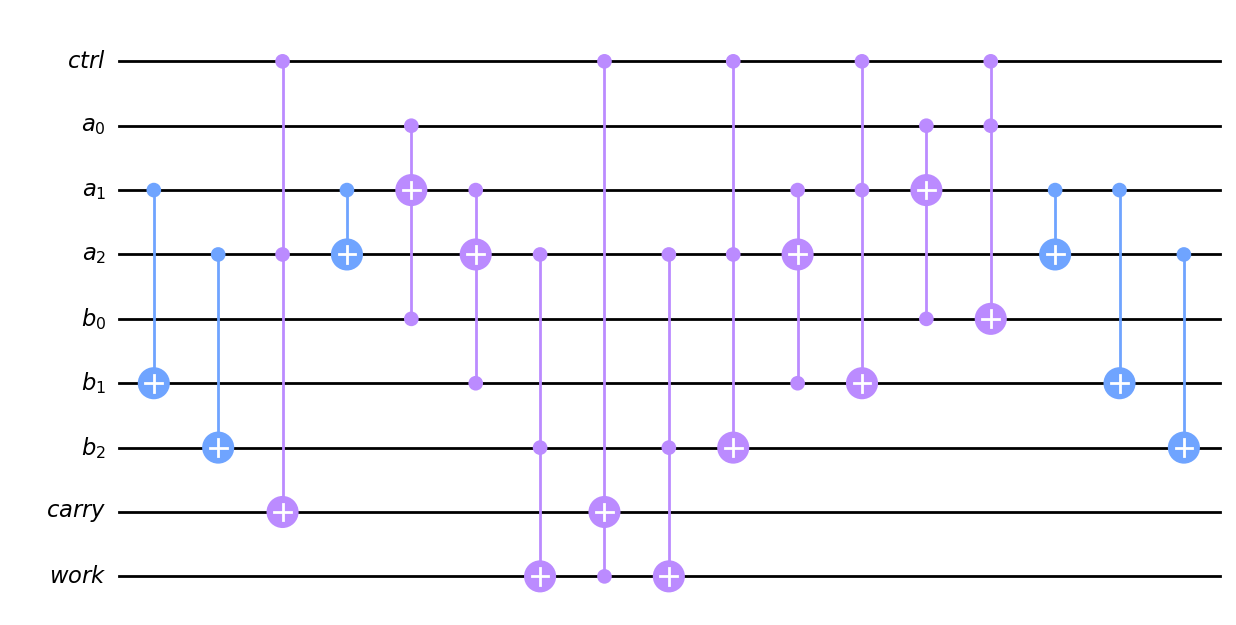

In [11]:
n = 3
ctrl = QuantumRegister(1, 'ctrl')
a = QuantumRegister(n, 'a')
b = QuantumRegister(n, 'b')
carry = QuantumRegister(1, 'carry')
work = QuantumRegister(1, 'work')
qc = QuantumCircuit(ctrl, a, b, carry, work)

basic_arithmetic_circuits.Conditional_addition_gate_inplace(
    qc, ctrl[0], a, b, carry[0], work[0],
    modular=False, useElementaryGates=False
)

mask = 2**n - 1
allTestsPassed = True
for ctrl_val in range(2):
    for a_val in range(2**n):
        for b_val in range(2**n):
            # Create the input state for given integers ctrl_val, a_val, and b_val
            integer_input = ctrl_val + (a_val << 1) + (b_val << (n + 1))
            bit_string_input = format(integer_input, '0' + str(qc.num_qubits) + 'b')
            input_state = Statevector.from_int(integer_input, dims=2**qc.num_qubits)

            # Apply the circuit to the state and get the output state
            output_state = input_state.evolve(qc)
            integer_output = int(np.argmax(np.abs(output_state.data)))
            bit_string_output = format(integer_output, '0' + str(qc.num_qubits) + 'b')
            output_ctrl = integer_output & 1
            output_a = (integer_output >> 1) & mask
            output_b = (integer_output >> (n + 1)) & (2**(n+1) - 1)
            output_work = (integer_output >> (2*n + 2)) & 1
            expected_sum = b_val + ctrl_val*a_val

            # print the input and output bit string for each test case
            #print("input: ", bit_string_input, "   ctrl = ", ctrl_val, "  a = ", a_val, "  b = ", b_val)
            #print("output: ", bit_string_output, "   ctrl = ", output_ctrl, "  a = ", output_a, "  b = ", output_b, "  work = ", output_work)

            # test that output is correct
            if output_ctrl != ctrl_val or output_a != a_val or output_b != expected_sum or output_work != 0:
                allTestsPassed = False
                print("output is not correct")
                print("input: ", bit_string_input, "   ctrl = ", ctrl_val, "  a = ", a_val, "  b = ", b_val)
                print("output: ", bit_string_output, "   ctrl = ", output_ctrl, "  a = ", output_a, "  b = ", output_b, "  carry = ", output_carry, "  work = ", output_work)
                #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
qc.draw('mpl')

# Out-of-place Modular Conditional Addition

$\ket{c}\ket{a}^n\ket{b}^n\ket{0}^n\ket{0} \rightarrow \ket{c}\ket{a}^n\ket{b}^n\ket{(b+ca) \% 2^n}^n\ket{0}$

All tests passed.


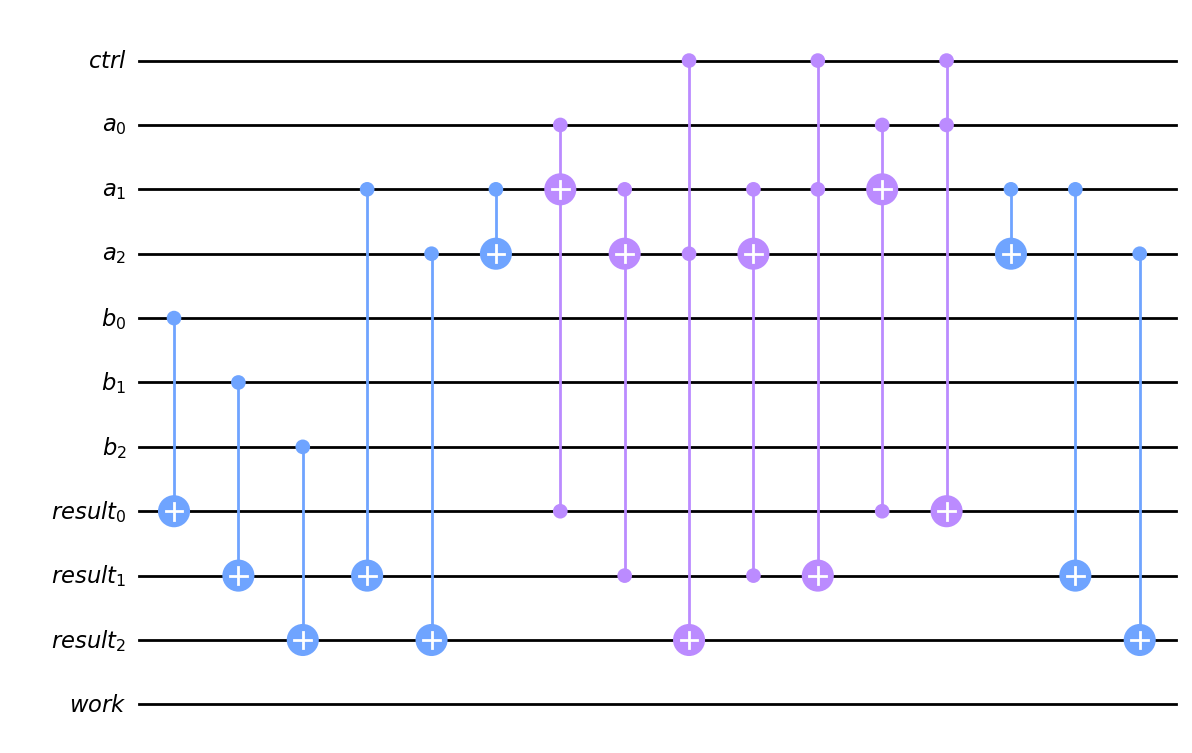

In [12]:
n = 3
ctrl = QuantumRegister(1, 'ctrl')
a = QuantumRegister(n, 'a')
b = QuantumRegister(n, 'b')
result = QuantumRegister(n, 'result')
work = QuantumRegister(1, 'work')
qc = QuantumCircuit(ctrl, a, b, result, work)

basic_arithmetic_circuits.Conditional_addition_gate_outofplace(
    qc, ctrl[0], a, b, result, work[0],
    modular=True, useElementaryGates=False
)

mask = 2**n - 1
allTestsPassed = True
for ctrl_val in range(2):
    for a_val in range(2**n):
        for b_val in range(2**n):
            # Create the input state for given integers ctrl_val, a_val, and b_val
            integer_input = ctrl_val + (a_val << 1) + (b_val << (n + 1))
            bit_string_input = format(integer_input, '0' + str(qc.num_qubits) + 'b')
            input_state = Statevector.from_int(integer_input, dims=2**qc.num_qubits)

            # Apply the circuit to the state and get the output state
            output_state = input_state.evolve(qc)
            integer_output = int(np.argmax(np.abs(output_state.data)))
            bit_string_output = format(integer_output, '0' + str(qc.num_qubits) + 'b')
            output_ctrl = integer_output & 1
            output_a = (integer_output >> 1) & mask
            output_b = (integer_output >> (n + 1)) & mask
            output_result = (integer_output >> (2*n + 1)) & mask
            output_work = (integer_output >> (3*n + 1)) & 1
            expected_sum = (b_val + ctrl_val*a_val) % 2**n

            # print the input and output bit string for each test case
            #print("input: ", bit_string_input, "   ctrl = ", ctrl_val, "  a = ", a_val, "  b = ", b_val)
            #print("output: ", bit_string_output, "   ctrl = ", output_ctrl, "  a = ", output_a, "  b = ", output_b, "  result = ", output_result, "  work = ", output_work)

            # test that output is correct
            if output_ctrl != ctrl_val or output_a != a_val or output_b != b_val or output_result != expected_sum or output_work != 0:
                allTestsPassed = False
                print("output is not correct")
                print("input: ", bit_string_input, "   ctrl = ", ctrl_val, "  a = ", a_val, "  b = ", b_val)
                print("output: ", bit_string_output, "   ctrl = ", output_ctrl, "  a = ", output_a, "  b = ", output_b, "  result = ", output_result, "  work = ", output_work)
                #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
qc.draw('mpl')

# Out-of-place Full Conditional Addition

$\ket{c}\ket{a}^n\ket{b}^n\ket{0}^{n+1}\ket{0} \rightarrow \ket{c}\ket{a}^n\ket{b}^n\ket{b+ca}^{n+1}\ket{0}$

All tests passed.


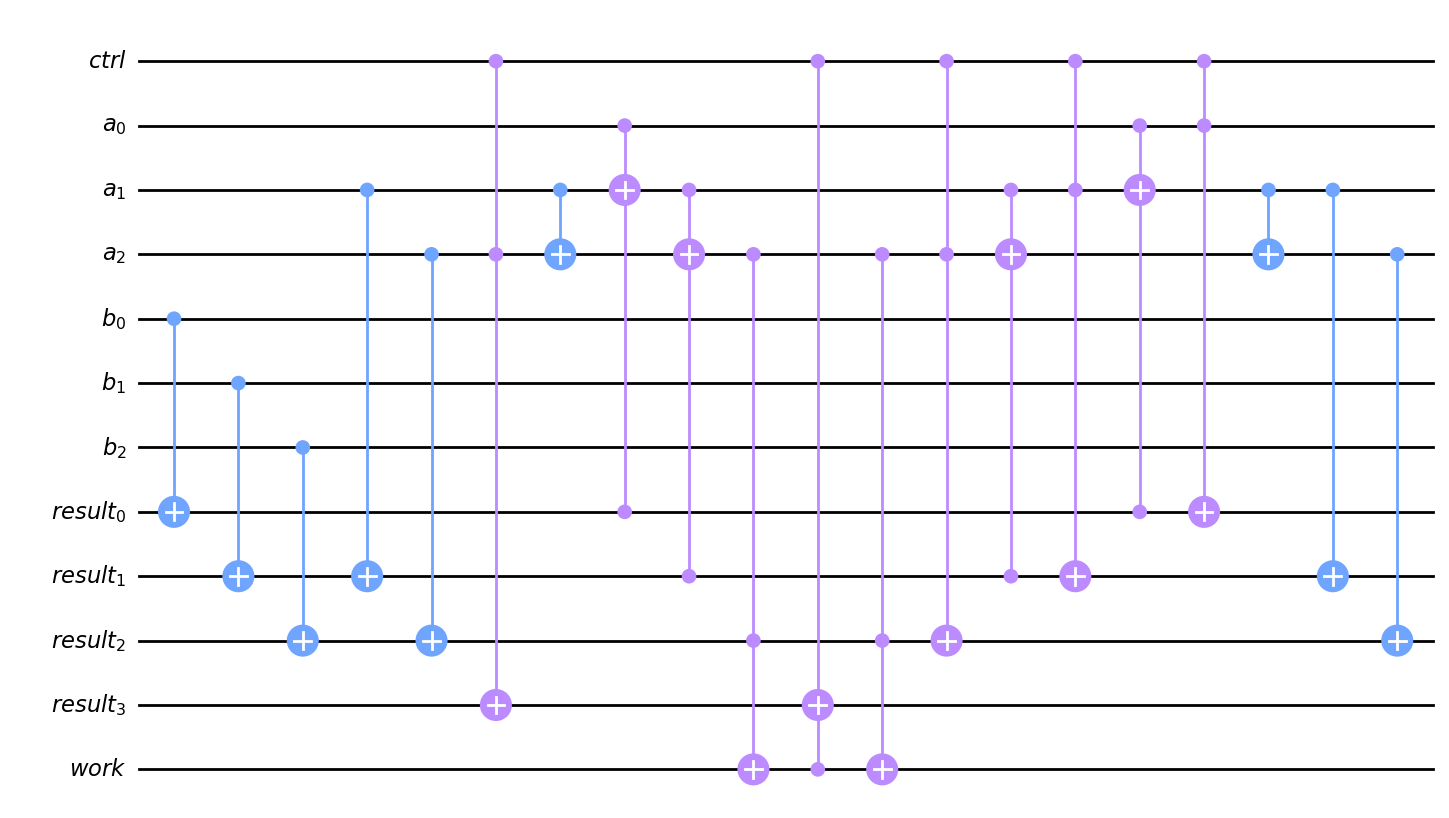

In [13]:
n = 3
ctrl = QuantumRegister(1, 'ctrl')
a = QuantumRegister(n, 'a')
b = QuantumRegister(n, 'b')
result = QuantumRegister(n + 1, 'result')
work = QuantumRegister(1, 'work')
qc = QuantumCircuit(ctrl, a, b, result, work)

basic_arithmetic_circuits.Conditional_addition_gate_outofplace(
    qc, ctrl[0], a, b, result, work[0],
    modular=False, useElementaryGates=False
)

mask = 2**n - 1
result_mask = 2**(n + 1) - 1
allTestsPassed = True
for ctrl_val in range(2):
    for a_val in range(2**n):
        for b_val in range(2**n):
            # Create the input state for given integers ctrl_val, a_val, and b_val
            integer_input = ctrl_val + (a_val << 1) + (b_val << (n + 1))
            bit_string_input = format(integer_input, '0' + str(qc.num_qubits) + 'b')
            input_state = Statevector.from_int(integer_input, dims=2**qc.num_qubits)

            # Apply the circuit to the state and get the output state
            output_state = input_state.evolve(qc)
            integer_output = int(np.argmax(np.abs(output_state.data)))
            bit_string_output = format(integer_output, '0' + str(qc.num_qubits) + 'b')
            output_ctrl = integer_output & 1
            output_a = (integer_output >> 1) & mask
            output_b = (integer_output >> (n + 1)) & mask
            output_result = (integer_output >> (2*n + 1)) & result_mask
            output_work = (integer_output >> (3*n + 2)) & 1
            expected_sum = b_val + ctrl_val*a_val

            # print the input and output bit string for each test case
            #print("input: ", bit_string_input, "   ctrl = ", ctrl_val, "  a = ", a_val, "  b = ", b_val)
            #print("output: ", bit_string_output, "   ctrl = ", output_ctrl, "  a = ", output_a, "  b = ", output_b, "  result = ", output_result, "  work = ", output_work)

            # test that output is correct
            if output_ctrl != ctrl_val or output_a != a_val or output_b != b_val or output_result != expected_sum or output_work != 0:
                allTestsPassed = False
                print("output is not correct")
                print("input: ", bit_string_input, "   ctrl = ", ctrl_val, "  a = ", a_val, "  b = ", b_val)
                print("output: ", bit_string_output, "   ctrl = ", output_ctrl, "  a = ", output_a, "  b = ", output_b, "  result = ", output_result, "  work = ", output_work)
                #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
qc.draw('mpl')

# Integer Multiplication

This section implements the shift-and-add construction from MuÃ±oz-Coreas and Thapliyal, *Quantum Circuit Design of a T-count Optimized Integer Multiplier* ([arXiv:1706.05113](https://arxiv.org/abs/1706.05113)). For two $n$-bit inputs, the circuit maps

$$\ket{a}^n \ket{b}^n \ket{0}^{2n+1} \longrightarrow \ket{a}^n \ket{b}^n \ket{a*b}^{2n} \ket{0}.$$

The first partial product is generated with a Toffoli array. Each later bit of $b$ controls the paper's seven-step conditional ripple-carry adder on a shifted slice of the product register. The final product occupies `p[0:2*n]`; `p[2*n]` is restored to zero.

All tests passed.
{'ccx': 25, 'cx': 12}


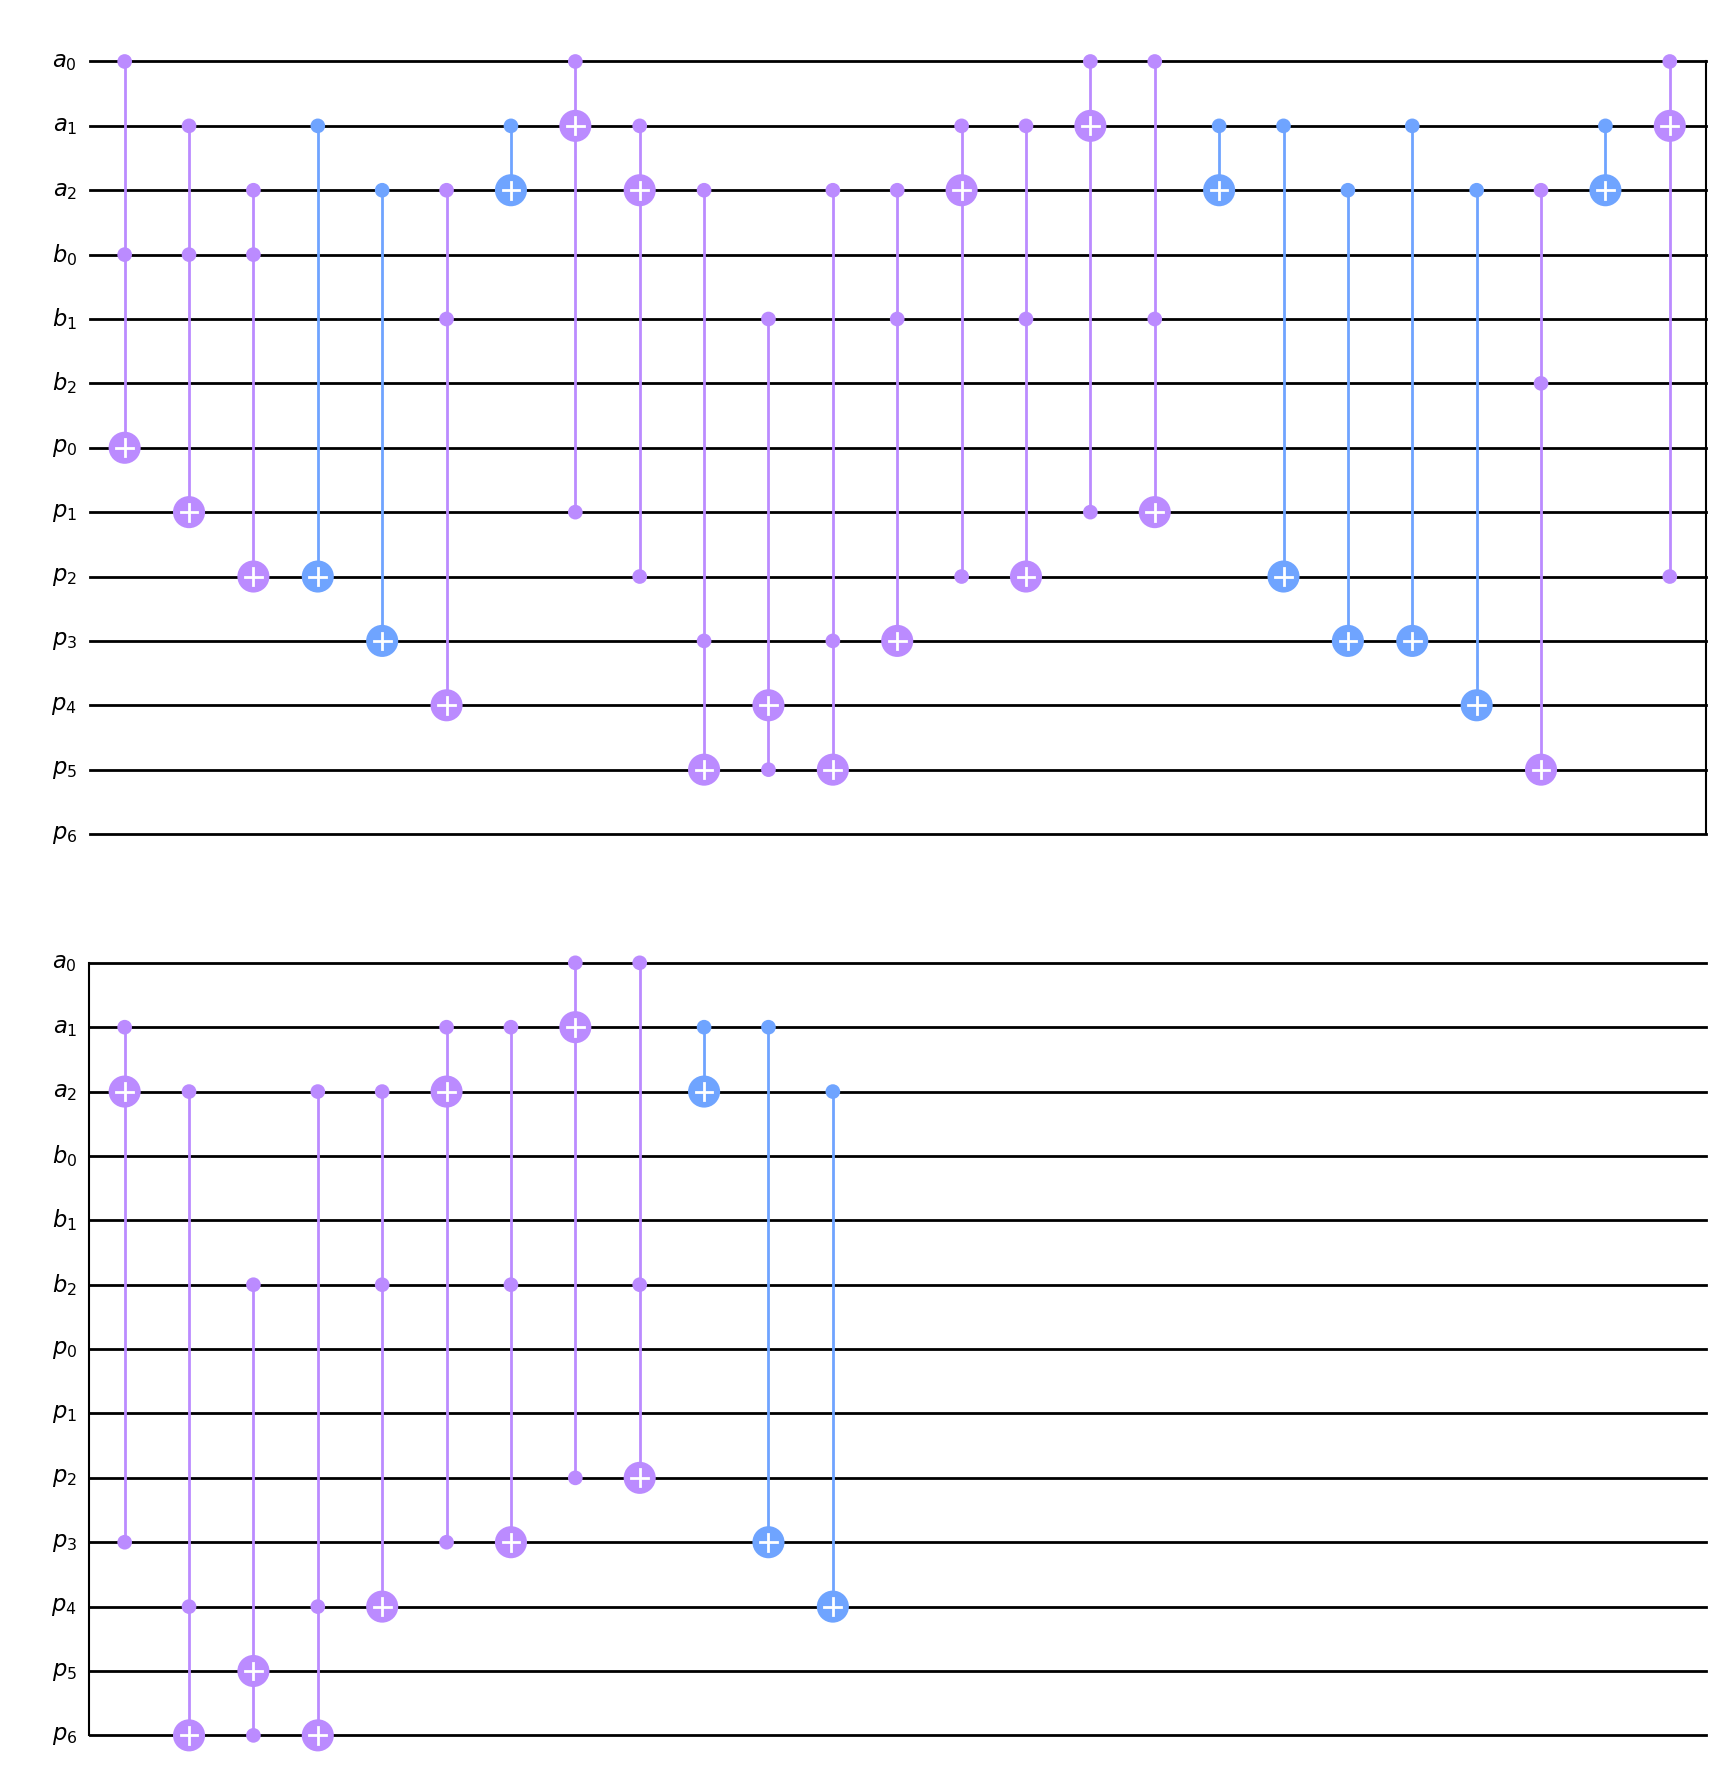

In [14]:
n = 3
a = QuantumRegister(n, 'a')
b = QuantumRegister(n, 'b')
p = QuantumRegister(2*n + 1, 'p')

qc = QuantumCircuit(a, b, p)
basic_arithmetic_circuits.Integer_multiplication_gate(qc, a, b, p, useElementaryGates=False)

# Exhaustively test all pairs of unsigned n-bit integers.
input_mask = 2**n - 1
product_mask = 2**(2*n) - 1
allTestsPassed = True
for a_val in range(2**n):
    for b_val in range(2**n):
        # Create the input state for given integers a_val and b_val
        integer_input = a_val | (b_val << n)
        bit_string_input = format(integer_input, '0' + str(qc.num_qubits) + 'b')
        input_state = Statevector.from_int(integer_input, dims=2**qc.num_qubits)

        # Apply the circuit to the state and get the output state
        output_state = input_state.evolve(qc)
        integer_output = int(np.argmax(np.abs(output_state.data)))
        bit_string_output = format(integer_output, '0' + str(qc.num_qubits) + 'b')
        output_a = integer_output & input_mask
        output_b = (integer_output >> n) & input_mask
        output_p = (integer_output >> (2*n)) & product_mask
        output_work = integer_output >> (4*n)

        # print the input and output bit string for each test case
        #print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
        #print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b, "  p = ", output_p, "  work = ", output_work)

        # test that output is correct
        if output_a != a_val or output_b != b_val or output_p != a_val * b_val or output_work != 0:
            allTestsPassed = False
            print("output is not correct")
            print("input: ", bit_string_input, "   a = ", a_val, "  b = ", b_val)
            print("output: ", bit_string_output, "   a = ", output_a, "  b = ", output_b, "  p = ", output_p, "  work = ", output_work)
            #raise Exception("output is not correct")

if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
print(dict(qc.count_ops()))
qc.draw('mpl')
